==> Membangun TRAIN (balanced via augment, ke embeddings)...
[TRAIN] audioanjing: 89 file → 2 crop/file (target≈120)
  Gagal: D:\web\cnn_clasification\archive\Data\genres_original\audioanjing\anjing10.wav time_stretch() takes 1 positional argument but 2 were given
  Gagal: D:\web\cnn_clasification\archive\Data\genres_original\audioanjing\anjing11.wav time_stretch() takes 1 positional argument but 2 were given
  Gagal: D:\web\cnn_clasification\archive\Data\genres_original\audioanjing\anjing12.wav time_stretch() takes 1 positional argument but 2 were given
  Gagal: D:\web\cnn_clasification\archive\Data\genres_original\audioanjing\anjing13.wav time_stretch() takes 1 positional argument but 2 were given
  Gagal: D:\web\cnn_clasification\archive\Data\genres_original\audioanjing\anjing15.wav time_stretch() takes 1 positional argument but 2 were given
  Gagal: D:\web\cnn_clasification\archive\Data\genres_original\audioanjing\anjing17.wav time_stretch() takes 1 positional argument but 2 were g

Model: "yamnet_head_small"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 1024)                │           4,096 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 256)                 │         262,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 8)                   │             520 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 283,464 (1.08 MB)

 Trainable params: 281,416 (1.07 MB)

 Non-trainable params: 2,048 (8.00 KB)

Epoch 1/60
 1/10 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.1562 - loss: 3.2814
Epoch 1: val_loss improved from None to 2.53203, saving model to best_yamnet_head.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.1383 - loss: 3.0670 - val_accuracy: 0.1322 - val_loss: 2.5320 - learning_rate: 0.0010
Epoch 2/60
 1/10 ━━━━━━━━━━━━━━━━━━━━ 2s 271ms/step - accuracy: 0.2188 - loss: 2.7243
Epoch 2: val_loss improved from 2.53203 to 2.48773, saving model to best_yamnet_head.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.1892 - loss: 2.7055 - val_accuracy: 0.1571 - val_loss: 2.4877 - learning_rate: 0.0010
Epoch 3/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2341 - loss: 2.5306  
Epoch 3: val_loss improved from 2.48773 to 2.45976, saving model to best_yamnet_head.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2496 - loss: 2.5231 - val_accuracy: 0.1809 - val_loss: 2.4598 - learning_rate: 0.0010
Epoch 4/60
 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - ac

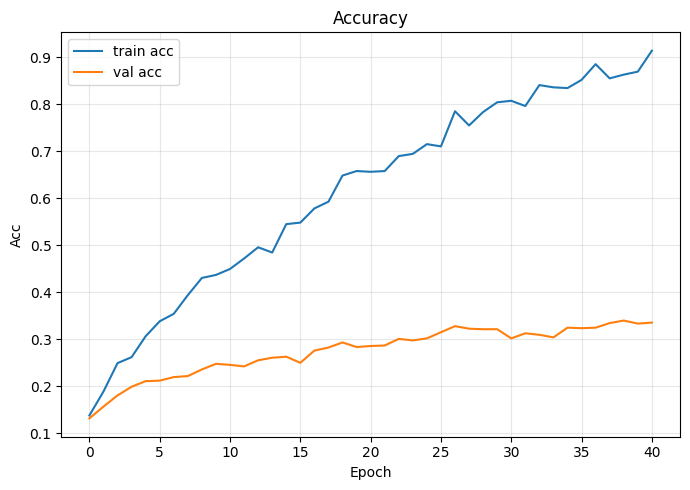

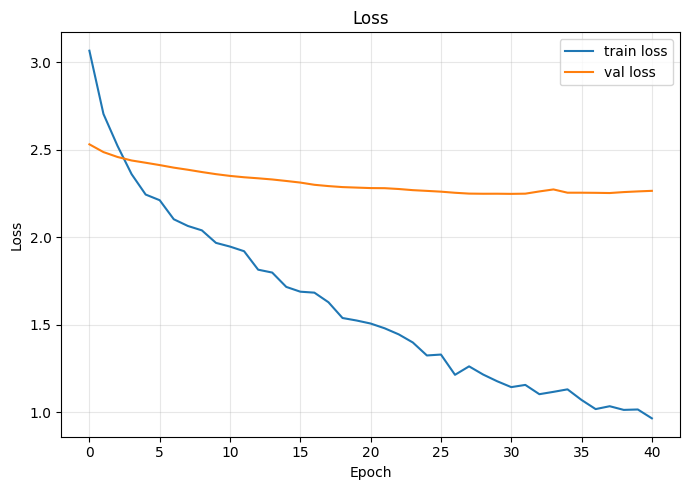

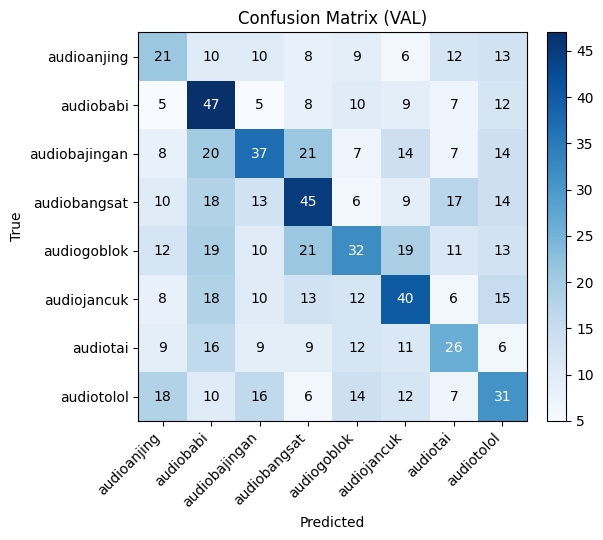

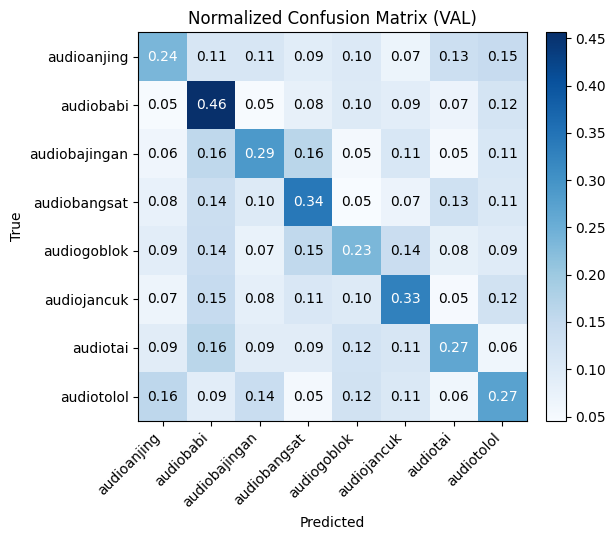

In [3]:
# ===================================================================
# Transfer Learning YAMNet (TF-Hub) untuk Klasifikasi Ujaran Kasar
# - Semua file dipakai
# - TRAIN diseimbangkan via augment sampai target per kelas (BALANCE_TO_PER_CLASS)
# - Segmen diambil dari top-K energi (RMS) + multi-scale window
# - Head MLP kecil dengan dropout & L2 + label smoothing
# - Evaluasi: accuracy, balanced accuracy, macro-F1, confmat, TTA
# ===================================================================

import os, random, warnings, sys, subprocess, importlib
warnings.filterwarnings("ignore")

# ------------ Install dependency bila perlu ------------
try:
    importlib.import_module("tensorflow_hub")
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow_hub==0.16.1"])

import numpy as np
from pathlib import Path
import librosa
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, balanced_accuracy_score, f1_score

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, regularizers
import tensorflow_hub as hub

# ------------ Konfigurasi ------------
DATA_DIR   = r"D:\web\cnn_clasification\archive\Data\genres_original"  # GANTI ke foldermu
SR_YAMNET  = 16000        # wajib 16 kHz mono
TOPK_TRAIN = 5            # ambil segmen dari K RMS tertinggi per file

# Multi-scale window (detik) — salah satu dipilih acak untuk tiap crop TRAIN
WIN_CHOICES = (0.8, 1.2, 2.0)
STEP_SEC    = 0.25        # hop untuk pemindaian RMS

# Target jumlah contoh TRAIN per kelas (semua kelas dinaikkan, tidak ada yang diturunkan)
BALANCE_TO_PER_CLASS = {
    "audioanjing":   120,
    "audiobabi":     120,
    "audiobajingan": 120,
    "audiobangsat":  120,
    "audiogoblok":   120,
    "audiojancuk":   120,
    "audiotai":      120,
    "audiotolol":    120,
}

SEED       = 42
LR         = 1e-3
EPOCHS     = 60
BATCH_SIZE = 64
DROPOUT    = 0.5
L2W        = 1e-3
LABEL_SMOOTH = 0.05

np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

# ------------ Util I/O & DSP ------------
def list_audio_files(root, exts=(".wav",".mp3",".flac",".ogg",".m4a",".WAV",".MP3",".FLAC")):
    root = Path(root)
    return [p for p in sorted(root.rglob("*")) if p.suffix in exts and p.is_file()]

def load_full_16k(path, sr=SR_YAMNET):
    y, _ = librosa.load(path, sr=sr, mono=True)
    if np.max(np.abs(y)) > 0:
        y = y / np.max(np.abs(y))
    # pre-emphasis kecil untuk kejelasan
    if len(y) > 1:
        y = np.append(y[0], y[1:] - 0.97 * y[:-1])
    return y.astype(np.float32)

def scan_rms(y, sr=SR_YAMNET, win_sec=1.0, step_sec=0.25):
    win  = int(win_sec * sr)
    step = int(step_sec * sr)
    if len(y) < win:
        y = np.pad(y, (0, win - len(y)))
    starts = np.arange(0, len(y) - win + 1, step, dtype=np.int32)
    if starts.size == 0:
        starts = np.array([0], dtype=np.int32)
    rms = np.array([np.sqrt(np.mean(y[s:s+win]**2)) + 1e-9 for s in starts], dtype=np.float32)
    return starts, rms, win

def crop_at(y, start, win):
    end = start + win
    if end > len(y):
        y = np.pad(y, (0, end - len(y)))
    return y[start:end]

def l2_normalize_audio(seg):
    rms = np.sqrt(np.mean(seg**2)) + 1e-9
    return (seg / rms).astype(np.float32)

# Augment ringan untuk TRAIN (acakan salah dua/tiga saja per segmen)
def augment(seg, sr=SR_YAMNET):
    x = seg.copy()
    if np.random.rand() < .5:
        rate = np.clip(np.random.normal(1.0, 0.06), 0.88, 1.12)
        x = librosa.effects.time_stretch(x, rate)
    if np.random.rand() < .5:
        steps = np.random.uniform(-1.0, 1.0)
        x = librosa.effects.pitch_shift(x, sr=sr, n_steps=steps)
    if np.random.rand() < .6:
        # noise SNR 15..30 dB
        noise = np.random.randn(len(x)).astype(np.float32)
        snr = np.random.uniform(15, 30)
        alpha = np.linalg.norm(x) / (10**(snr/20) * np.linalg.norm(noise) + 1e-9)
        x = x + alpha * noise
    return x.astype(np.float32)

# ------------ YAMNet embeddings ------------
yamnet = hub.KerasLayer("https://tfhub.dev/google/yamnet/1",
                        trainable=False, name="yamnet")

@tf.function
def yamnet_embed_tf(waveform):
    # YAMNet returns (scores, embeddings, spectrogram)
    scores, embeddings, spect = yamnet(waveform)
    return embeddings  # [frames, 1024] atau [batch, frames, 1024]

def embed_clip_numpy(seg_16k):
    wf = tf.convert_to_tensor(seg_16k, dtype=tf.float32)
    emb = yamnet_embed_tf(wf)                  # [frames, 1024]
    emb = tf.reduce_mean(emb, axis=0)          # mean pooling → [1024]
    return emb.numpy().astype(np.float32)

# ------------ Dataset builder (ke embedding) ------------
def build_yamnet_dataset(data_dir, mode="train",
                         balance_to_per_class=None,
                         win_choices=WIN_CHOICES,
                         step_sec=STEP_SEC,
                         topk_train=TOPK_TRAIN):
    """
    mode='train': upsampling via augment hingga target per kelas (tanpa buang file).
    mode='val'  : 1 segmen RMS tertinggi per file (deterministik; pakai win terbesar).
    Output:
      X_emb [N,1024], y [N], class_names, paths [N]
    """
    root = Path(data_dir)
    class_names = sorted([d.name for d in root.iterdir() if d.is_dir()])
    X_emb, Y, paths = [], [], []

    for ci, cname in enumerate(class_names):
        files = list_audio_files(root / cname)
        if mode == "train" and balance_to_per_class is not None:
            target = int(balance_to_per_class.get(cname, len(files)))
            # minimal 1 crop/file lalu tambah pengulangan
            rep = max(1, int(np.ceil(target / max(1, len(files)))))
        else:
            target = len(files)
            rep = 1

        print(f"[{mode.upper()}] {cname}: {len(files)} file → {rep} crop/file (target≈{target})")
        for f in files:
            try:
                y_full = load_full_16k(str(f))
                # WIN untuk VAL: pakai yang terpanjang agar robust
                if mode == "val":
                    win_sel = max(win_choices)
                    starts, rms, win = scan_rms(y_full, win_sec=win_sel, step_sec=step_sec)
                    s = int(np.argmax(rms))
                    seg = crop_at(y_full, starts[s], win)
                    seg = l2_normalize_audio(seg)
                    emb = embed_clip_numpy(seg)     # [1024]
                    X_emb.append(emb); Y.append(ci); paths.append(str(f))
                    continue

                # TRAIN: ambil dari top-K RMS, window acak (multi-scale), augment
                # Pindai dengan win terbesar supaya kandidat start-nya tidak terlalu sempit
                win_big = max(win_choices)
                starts, rms, win_big_n = scan_rms(y_full, win_sec=win_big, step_sec=step_sec)
                if len(rms) == 0:
                    continue
                pick_idx = np.argsort(rms)[::-1][:min(topk_train, len(rms))]

                for _ in range(rep):
                    # pilih window acak & start acak dari top-K
                    win_sec = random.choice(win_choices)
                    win_n = int(win_sec * SR_YAMNET)
                    s0 = int(np.random.choice(pick_idx))
                    start = int(starts[s0])  # pos di basis win_big
                    # sesuaikan supaya tidak keluar batas
                    if start + win_n > len(y_full):
                        start = max(0, len(y_full) - win_n)
                    seg = crop_at(y_full, start, win_n)
                    if np.random.rand() < 0.9:
                        seg = augment(seg)
                    seg = l2_normalize_audio(seg)
                    emb = embed_clip_numpy(seg)
                    X_emb.append(emb); Y.append(ci); paths.append(str(f))
            except Exception as e:
                print("  Gagal:", f, e)

    X_emb = np.stack(X_emb, axis=0).astype(np.float32)
    Y = np.array(Y, dtype=np.int64)
    return X_emb, Y, class_names, np.array(paths)

print("==> Membangun TRAIN (balanced via augment, ke embeddings)...")
Xtr, ytr, class_names, _ = build_yamnet_dataset(
    DATA_DIR, mode="train", balance_to_per_class=BALANCE_TO_PER_CLASS
)
print("==> Membangun VAL (deterministik, 1 segmen/file)...")
Xval, yval, _, _ = build_yamnet_dataset(DATA_DIR, mode="val")

print("Shapes (emb): TRAIN", Xtr.shape, "VAL", Xval.shape, "| num_classes:", len(class_names), class_names)

# ------------ Head classifier (kecil + regularisasi) ------------
def build_head(input_dim, num_classes, l2w=L2W, drop=DROPOUT):
    inp = layers.Input(shape=(input_dim,))
    x = layers.BatchNormalization()(inp)
    x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(l2w))(x)
    x = layers.Dropout(drop)(x)
    x = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(l2w))(x)
    x = layers.Dropout(drop)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return models.Model(inp, out, name="yamnet_head_small")

num_classes = len(class_names)
head = build_head(1024, num_classes)
head.summary()

# ---- Loss kustom: Sparse CE + label smoothing (kompatibel tf_keras lama) ----
def make_sparse_ce_with_smoothing(smoothing, num_classes):
    base_cce = tf.keras.losses.CategoricalCrossentropy()  # tanpa smoothing
    smoothing = float(smoothing)

    def loss(y_true, y_pred):
        # y_true: [B] integer class
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_true_oh = tf.one_hot(y_true, depth=num_classes, dtype=tf.float32)
        if smoothing > 0.0:
            y_true_oh = y_true_oh * (1.0 - smoothing) + smoothing / num_classes
        return base_cce(y_true_oh, y_pred)

    return loss

# ---- Compile head ----
loss_fn = make_sparse_ce_with_smoothing(LABEL_SMOOTH, num_classes)
head.compile(optimizer=optimizers.Adam(LR), loss=loss_fn, metrics=["accuracy"])

cbs = [
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1),
    callbacks.ModelCheckpoint("best_yamnet_head.keras", monitor="val_loss", save_best_only=True, verbose=1),
]

hist = head.fit(
    Xtr, ytr,
    validation_data=(Xval, yval),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cbs,
    verbose=1
)

# ------------ Evaluasi ------------
yprob = head.predict(Xval, verbose=0)
ypred = np.argmax(yprob, axis=1)

print("\nVal accuracy        :", accuracy_score(yval, ypred))
print("Balanced accuracy   :", balanced_accuracy_score(yval, ypred))
print("Macro F1            :", f1_score(yval, ypred, average="macro"))
print("\nClassification report:\n", classification_report(yval, ypred, target_names=class_names, digits=4))

cm = confusion_matrix(yval, ypred)
print("Confusion:\n", cm)

# ------------ Plot training curve & CM ------------
def plot_history(h):
    plt.figure(figsize=(7,5))
    plt.plot(h.history["accuracy"], label="train acc")
    plt.plot(h.history["val_accuracy"], label="val acc")
    plt.xlabel("Epoch"); plt.ylabel("Acc"); plt.title("Accuracy")
    plt.grid(alpha=.3); plt.legend(); plt.tight_layout(); plt.show()

    plt.figure(figsize=(7,5))
    plt.plot(h.history["loss"], label="train loss")
    plt.plot(h.history["val_loss"], label="val loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss")
    plt.grid(alpha=.3); plt.legend(); plt.tight_layout(); plt.show()

def plot_cm(cm, class_names, normalize=False, title="Confusion Matrix"):
    import numpy as np
    import matplotlib.pyplot as plt

    data = np.array(cm, dtype=float)

    if normalize:
        row_sums = data.sum(axis=1, keepdims=True) + 1e-9
        data = data / row_sums
        fmt = ".2f"
        disp = data
    else:
        fmt = ".0f"
        disp = np.around(data).astype(int)  # tampilkan integer

    plt.figure(figsize=(6.5, 5.5))
    im = plt.imshow(disp if not normalize else data, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title(title); plt.colorbar(im, fraction=0.046, pad=0.04)

    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45, ha="right")
    plt.yticks(ticks, class_names)

    thresh = (disp if not normalize else data).max() / 2.0
    for i in range(disp.shape[0]):
        for j in range(disp.shape[1]):
            plt.text(
                j, i,
                format((disp if not normalize else data)[i, j], fmt),
                ha="center", va="center",
                color="white" if (disp if not normalize else data)[i, j] > thresh else "black"
            )

    plt.ylabel("True"); plt.xlabel("Predicted")
    plt.tight_layout(); plt.show()


plot_history(hist)
plot_cm(cm, class_names, normalize=False, title="Confusion Matrix (VAL)")
plot_cm(cm, class_names, normalize=True,  title="Normalized Confusion Matrix (VAL)")

# ------------ TTA (multi-crop voting) untuk 1 file ------------
def predict_file_tta(file_path, head_model, class_names,
                     win_choices=(0.8, 1.2, 2.0),
                     starts_sec=(0.0, 0.25, 0.5, 0.75, 1.0),
                     sr=SR_YAMNET):
    y = load_full_16k(file_path, sr=sr)
    probs = []
    for w in win_choices:
        win = int(w * sr)
        for st in starts_sec:
            s = int(st * sr); e = s + win
            if e > len(y):
                seg = np.pad(y[s:], (0, e - len(y)))
            else:
                seg = y[s:e]
            seg = l2_normalize_audio(seg)
            emb = embed_clip_numpy(seg)[None, :]
            p = head_model.predict(emb, verbose=0)[0]
            probs.append(p)
    p_mean = np.mean(probs, axis=0)
    cls = int(np.argmax(p_mean))
    return class_names[cls], p_mean

# Contoh pakai TTA:
# pred_label, prob = predict_file_tta(r"D:\path\to\audio.wav", head, class_names)
# print("Prediksi:", pred_label, "| Prob:", prob)
